# Tag Recommendation Experiment (RecSys 2018)

Notebook simple et modulaire pour reproduire une expérience inspirée de l'article **Semantic-based Tag Recommendation in Scientific Bookmarking Systems**.

- Import des données : **1 cellule**
- Une fonction par cellule
- Visualisations déplacées dans `src/visualization.py`
- Dernière cellule : compilation des résultats + visualisations comparatives

In [1]:
# Cellule 1 - Imports (meme stack que l'article)
import sys
from pathlib import Path
import subprocess
import os
import datetime

import tensorflow as tf
tf.config.set_visible_devices([], "GPU")
print(tf.config.list_physical_devices("GPU"))  # should be []

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import load_citeulike_a_dataset, keep_top_k_tags, preprocess_text_nltk, text_length_stats
from src.experiment import prepare_train_test, run_all_models
from src.visualization import (
    plot_tag_distribution,
    plot_text_length_distributions,
    plot_model_metrics,
    plot_article_vs_current,
)

# pd.set_option("display.max_colwidth", 120)

2026-04-16 13:14:58.941521: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 13:14:58.949970: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-16 13:14:58.959439: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-16 13:14:58.962356: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-16 13:14:58.970053: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cellule 2 - Paramètres globaux
DATA_PATH = Path(PROJECT_ROOT / "data" / "citeulike-a")
if not os.path.exists(DATA_PATH):
    print("target =", DATA_PATH.resolve())
    print("exists =", DATA_PATH.exists())
    if not DATA_PATH.exists():
        DATA_PATH.mkdir(parents=True, exist_ok=True)
        result = subprocess.run(
            ["bash","-c", f"git clone https://github.com/js05212/citeulike-a.git data/citeulike-a"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", f"ls -la {DATA_PATH}"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
GLOVE_PATH = Path(PROJECT_ROOT / "data" / "glove.6B.300d.txt")
if not os.path.exists(GLOVE_PATH):
    print("target =", GLOVE_PATH.resolve())
    print("exists =", GLOVE_PATH.exists())
    if not GLOVE_PATH.exists():
        result = subprocess.run(
            ["bash","-c", "curl -L -o data/glove.6B.zip \
            https://nlp.stanford.edu/data/glove.6B.zip"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "ls -la data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", "unzip data/glove.6B.zip -d data"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
        result = subprocess.run(
            ["bash","-c", f"ls -la {GLOVE_PATH}"],
            capture_output=True,
            text=True,
            check=False
        )
        print(result.stdout)
TOP_K_TAGS = 10
TEST_SIZE = 0.1
RANDOM_STATE = 42

In [3]:
# Cellule 3 - Import des données (simple, en une cellule)
def import_data(csv_path: str | Path, top_k_tags: int = 10):
    df = load_citeulike_a_dataset(csv_path)
    df = keep_top_k_tags(df, top_k=top_k_tags)
    df = preprocess_text_nltk(df)
    return text_length_stats(df)


df = import_data(DATA_PATH, TOP_K_TAGS)
df.head()

/workspace/data/citeulike-a/citations.dat
/workspace/data/citeulike-a/item-tag.dat
/workspace/data/citeulike-a/mult.dat
/workspace/data/citeulike-a/tags.dat
/workspace/data/citeulike-a/users.dat
/workspace/data/citeulike-a/vocabulary.dat


,title,abstract,tags,text,tag_list,processed_text,title_words,abstract_words,text_words,num_tags
0,the metabolic world of escherichia coli is not...,To elucidate the organizational and evolutiona...,dissertation|metabolism|network|metabolic_netw...,the metabolic world of escherichia coli is not...,"[network, review, networks]",metabolic world escherichia coli small elucida...,9,174,119,3
1,reverse engineering of biological complexity,Advanced technologies and biology have extreme...,behaviors|control|controllability|key--systems...,reverse engineering of biological complexity. ...,"[networks, network, review, evolution]",reverse engineering biological complexity adva...,5,123,82,4
2,exploring complex networks,"The study of networks pervades all of science,...",scalefree|bistability|senior-project|complex-n...,exploring complex networks. The study of netwo...,"[networks, statistics, network, review]",exploring complex network study network pervad...,3,99,63,4
3,comparative assessment of largescale data sets...,Comprehensive protein protein interaction maps...,false|features|pin|network_confidence|ppi|two-...,comparative assessment of largescale data sets...,"[networks, network, statistics, bioinformatics...",comparative assessment largescale data set pro...,9,61,48,5
4,navigation in a small world,The small-world phenomenon â the principle t...,diktyology|complex-networks|filing-small-world...,navigation in a small world. The small-world p...,"[networks, network, analysis]",navigation small world small world phenomenon ...,5,103,60,3


In [4]:
# Cellule 4 - Fonction de résumé exploration
def summarize_dataset(df: pd.DataFrame) -> pd.DataFrame:
    summary = {
        "num_documents": [len(df)],
        "num_unique_tags": [len({t for tags in df["tag_list"] for t in tags})],
        "avg_title_words": [df["title_words"].mean()],
        "avg_abstract_words": [df["abstract_words"].mean()],
        "avg_tags_per_doc": [df["num_tags"].mean()],
    }
    return pd.DataFrame(summary)


summarize_dataset(df)

,num_documents,num_unique_tags,avg_title_words,avg_abstract_words,avg_tags_per_doc
0,6397,10,8.849304,180.848835,1.802251


/workspace/src/visualization.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")


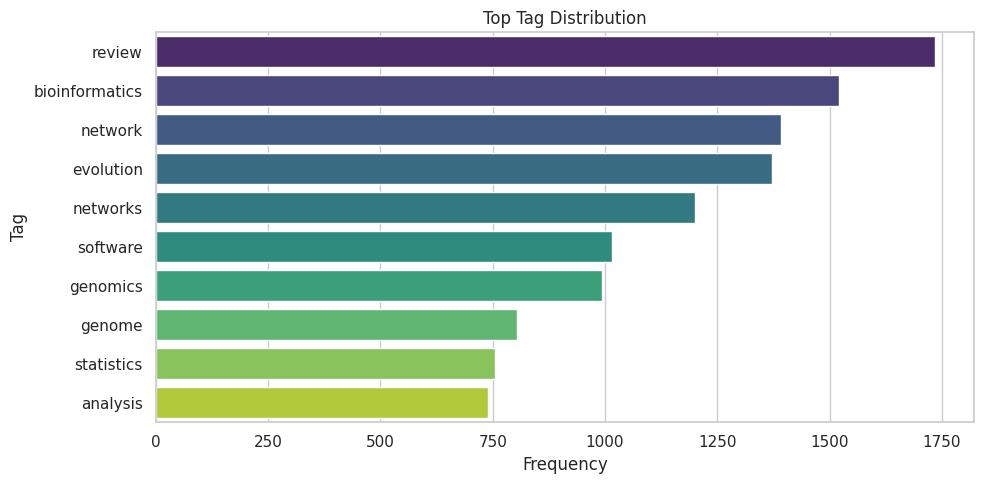

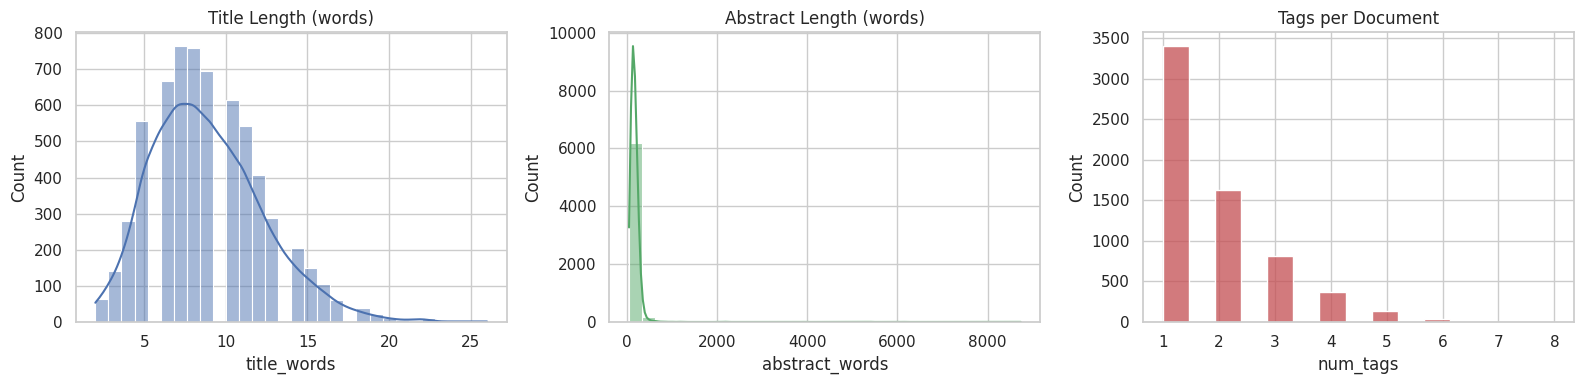

In [5]:
# Cellule 5 - Fonction visualisation EDA
def visualize_eda(df: pd.DataFrame):
    fig1 = plot_tag_distribution(df, top_n=TOP_K_TAGS)
    fig2 = plot_text_length_distributions(df)
    plt.show()
    return fig1, fig2


_ = visualize_eda(df)

In [6]:
# Cellule 6 - Préparation train/test
def make_splits(df: pd.DataFrame):
    return prepare_train_test(
        df,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )


X_train, X_test, y_train, y_test, mlb = make_splits(df)
print("Train:", len(X_train), "Test:", len(X_test), "Labels:", len(mlb.classes_))

Train: 5757 Test: 640 Labels: 10


In [7]:
# Cellule 7 - Entraînement de tous les modèles
def train_models(X_train, X_test, y_train, y_test, n_topics: int, glove_path: str):
    return run_all_models(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        n_topics=n_topics,
        glove_path=glove_path,
    )

# with tf.device("/CPU:0"):
metrics_df, predictions = train_models(
    X_train,
    X_test,
    y_train,
    y_test,
    n_topics=TOP_K_TAGS,
    glove_path=GLOVE_PATH,
)
metrics_df

I0000 00:00:1776345362.423376   13040 service.cc:146] XLA service 0x7f1ccc03fa50 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776345362.423390   13040 service.cc:154]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1776345362.432677   13030 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


,name,micro_recall,micro_precision,micro_f1
0,SVM,0.540728,0.715596,0.615992
1,NB,0.759965,0.491041,0.596599
2,Paragraph Vector,0.531196,0.648677,0.584088
3,LDA,0.236568,0.712794,0.355237
4,Bi-GRU+Att,0.000000,0.000000,0.000000


In [ ]:
# Cellule 8 - Sauvegarde facultative des métriques
import json
import uuid
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd

def save_metrics_enriched(
    metrics_df: pd.DataFrame,
    output_csv: str = "data/metrics_results_history.csv",
    *,
    dataset_path: str = "data/citeulike-a",
    top_k_tags: int = 10,
    test_size: float = 0.1,
    random_state: int = 42,
    repeats: int = 1,
    threshold: float = 0.5,
    text_column: str = "processed_text",
    n_docs: int | None = None,
    n_unique_tags: int | None = None,
    avg_tags_per_doc: float | None = None,
    glove_path: str | None = "data/glove.6B.300d.txt",
    model_params: dict | None = None,
    predictions: dict[str, np.ndarray] | None = None,
    y_test: np.ndarray | None = None,
    notes: str = "",
):
    run_id = uuid.uuid4().hex[:12]
    ts = datetime.utcnow().isoformat(timespec="seconds") + "Z"

    out = metrics_df.copy()

    # Global experiment metadata
    out["run_id"] = run_id
    out["timestamp_utc"] = ts
    out["dataset_path"] = dataset_path
    out["top_k_tags"] = top_k_tags
    out["test_size"] = test_size
    out["random_state"] = random_state
    out["repeats"] = repeats
    out["threshold"] = threshold
    out["text_column"] = text_column
    out["n_docs"] = n_docs
    out["n_unique_tags"] = n_unique_tags
    out["avg_tags_per_doc"] = avg_tags_per_doc
    out["glove_path"] = glove_path
    out["notes"] = notes

    # Per-model params JSON
    model_params = model_params or {}
    out["model_params_json"] = out["name"].map(
        lambda m: json.dumps(model_params.get(m, {}), ensure_ascii=False, sort_keys=True)
    )

    # Optional prediction diagnostics
    if predictions is not None:
        out["pred_pos_rate"] = out["name"].map(
            lambda m: float(np.mean(predictions[m])) if m in predictions else np.nan
        )
        out["pred_avg_labels_per_doc"] = out["name"].map(
            lambda m: float(np.sum(predictions[m], axis=1).mean()) if m in predictions else np.nan
        )
    else:
        out["pred_pos_rate"] = np.nan
        out["pred_avg_labels_per_doc"] = np.nan

    if y_test is not None:
        out["y_test_pos_rate"] = float(np.mean(y_test))
        out["y_test_avg_labels_per_doc"] = float(np.sum(y_test, axis=1).mean())
    else:
        out["y_test_pos_rate"] = np.nan
        out["y_test_avg_labels_per_doc"] = np.nan

    # Append to history file
    output_path = Path(output_csv)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists():
        prev = pd.read_csv(output_path)
        out = pd.concat([prev, out], ignore_index=True)

    out.to_csv(output_path, index=False)
    return output_path, run_id

    
model_params = {
    "NB": {"vectorizer": "CountVectorizer", "max_features": 8000, "ngram_range": [1, 1], "threshold": 0.5},
    "SVM": {"vectorizer": "TfidfVectorizer", "max_features": 8000, "classifier": "LinearSVC", "threshold": 0.0},
    "LDA": {"num_topics": TOP_K_TAGS, "passes": 10, "iterations": 100, "threshold": 0.5},
    "Paragraph Vector": {"vector_size": 200, "window": 3, "epochs": 20, "threshold": 0.5},
    "Bi-GRU+Att": {"max_words": 15000, "max_len": 300, "gru_units": 25, "dense_units": 50, "dropout": 0.2, "epochs": 5, "batch_size": 64, "threshold": 0.5},
}

save_metrics_enriched(
    metrics_df=metrics_df,
    predictions=predictions,
    y_test=y_test,
    top_k_tags=TOP_K_TAGS,
    test_size=0.1,
    random_state=42,
    repeats=1,
    threshold=0.5,
    n_docs=len(df),
    n_unique_tags=len({t for tags in df["tag_list"] for t in tags}),
    avg_tags_per_doc=float(df["tag_list"].apply(len).mean()),
    glove_path=str(GLOVE_PATH),
    model_params=model_params,
    notes="first stable docker run",
)



def save_metrics(metrics_df: pd.DataFrame, output_csv: str = "data/metrics_results.csv"):
    output_csv = f"data/metrics_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    metrics_df.to_csv(output_csv, index=False)
    return output_csv


save_metrics(metrics_df)

/tmp/ipykernel_12877/3392267944.py:30: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().isoformat(timespec="seconds") + "Z"


'data/metrics_results_20260416_131616.csv'

,name,micro_recall,micro_precision,micro_f1
0,SVM,0.540728,0.715596,0.615992
1,NB,0.759965,0.491041,0.596599
2,Paragraph Vector,0.531196,0.648677,0.584088
3,LDA,0.236568,0.712794,0.355237
4,Bi-GRU+Att,0.000000,0.000000,0.000000


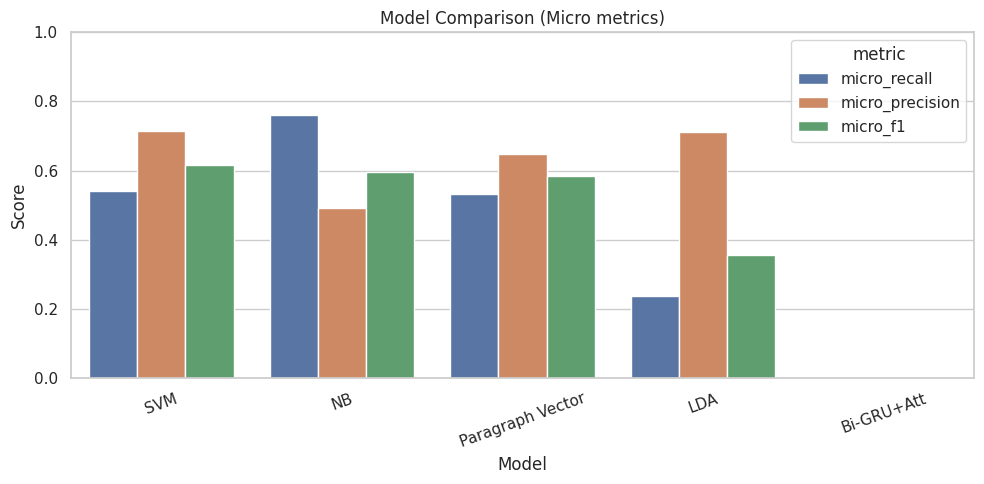

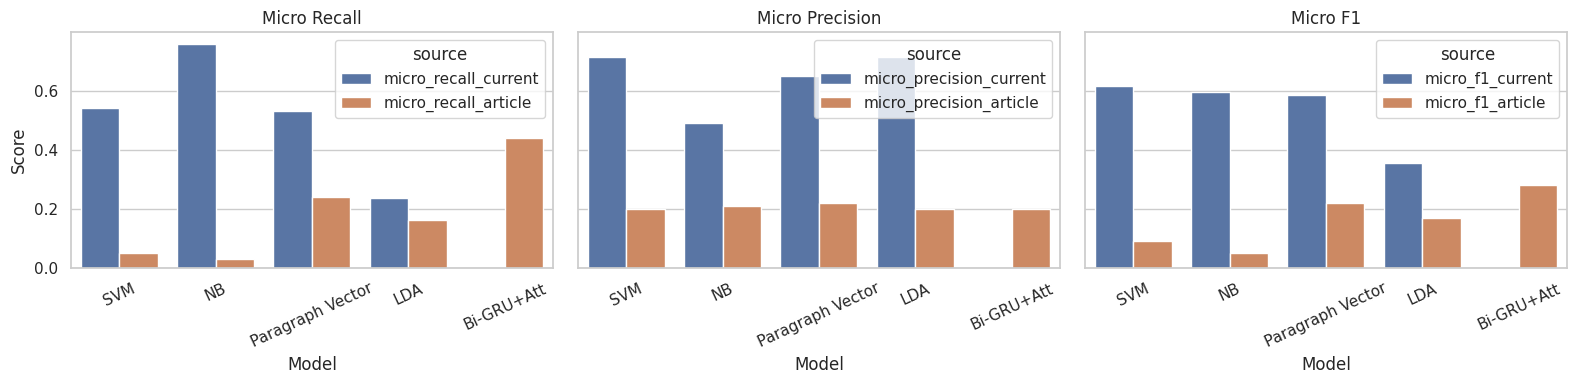

{'best_model': 'SVM', 'best_micro_f1': 0.6159921026653504}

In [9]:
# Cellule 9 (dernière) - Compilation + visualisations comparatives
def compile_and_compare(metrics_df: pd.DataFrame):
    display(metrics_df.sort_values("micro_f1", ascending=False).reset_index(drop=True))

    fig_models = plot_model_metrics(metrics_df)
    fig_article = plot_article_vs_current(metrics_df)
    plt.show()

    return {
        "best_model": metrics_df.sort_values("micro_f1", ascending=False).iloc[0]["name"],
        "best_micro_f1": float(metrics_df["micro_f1"].max()),
    }


summary = compile_and_compare(metrics_df)
summary